#Air Quality Prediction

In this our problem statement was to predict the Air Quality Index (1 to 5) using weather and pollution sensor data.
This is a multi- class classification problem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loaded the dataset

In [2]:
df = pd.read_csv('train.csv')
df.head()

,UtcTime,LocalDate,LocalHour,SineDay,CosineDay,SineWeek,CosineWeek,SineMonth,CosineMonth,SineYear,...,LevelCO,LevelNO,LevelNO2,LevelO3,LevelSO2,LevelNH3,LevelPM2,LevelPM10,AirQuality,dt
0,1606266000,2020-11-25,3,0.2588,0.9659,0.9659,-0.2588,-0.9483,0.3173,-0.5928,...,223.64,0.00,4.24,49.35,3.46,0.46,3.18,5.08,1,2020-11-25 03:00:00
1,1606269600,2020-11-25,4,0.5000,0.8660,0.9556,-0.2948,-0.9455,0.3256,-0.5922,...,226.97,0.00,4.33,48.64,3.73,0.47,3.10,4.89,1,2020-11-25 04:00:00
2,1606273200,2020-11-25,5,0.7071,0.7071,0.9439,-0.3303,-0.9426,0.3338,-0.5916,...,230.31,0.00,4.80,46.49,4.05,0.45,3.72,5.50,1,2020-11-25 05:00:00
3,1606276800,2020-11-25,6,0.8660,0.5000,0.9309,-0.3653,-0.9397,0.3420,-0.5910,...,233.65,0.01,5.83,43.63,4.59,0.48,4.49,6.33,1,2020-11-25 06:00:00
4,1606280400,2020-11-25,7,0.9659,0.2588,0.9166,-0.3999,-0.9367,0.3502,-0.5904,...,243.66,0.02,8.82,39.34,5.25,0.55,5.24,7.22,1,2020-11-25 07:00:00


In [3]:
df.shape

(27090, 31)

In [4]:
df.describe()

,UtcTime,LocalHour,SineDay,CosineDay,SineWeek,CosineWeek,SineMonth,CosineMonth,SineYear,CosineYear,...,CloudLevel,LevelCO,LevelNO,LevelNO2,LevelO3,LevelSO2,LevelNH3,LevelPM2,LevelPM10,AirQuality
count,2.709000e+04,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,...,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000,27090.000000
mean,1.655026e+09,11.500000,0.000122,-0.000159,0.000720,-0.001196,-0.002002,0.001356,-0.009975,0.027745,...,66.840052,249.038417,1.567568,9.026033,49.211901,6.122869,1.645839,5.848555,7.121259,1.377889
std,2.815327e+07,6.921306,0.707120,0.707093,0.706957,0.707282,0.707420,0.706819,0.699302,0.714242,...,37.670466,54.728013,7.152939,9.307642,25.706463,4.642353,1.828732,5.753879,7.171227,0.600631
min,1.606266e+09,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,0.000000,143.530000,0.000000,0.470000,0.000000,0.750000,0.000000,0.500000,0.560000,1.000000
25%,1.630646e+09,6.000000,-0.707100,-0.707100,-0.707100,-0.707100,-0.707100,-0.707100,-0.689700,-0.689700,...,32.000000,208.620000,0.010000,3.300000,31.470000,3.400000,0.700000,2.460000,3.080000,1.000000
50%,1.655026e+09,11.500000,0.000000,-0.000000,0.000000,-0.000000,0.000000,0.000000,-0.048300,0.048400,...,88.000000,243.660000,0.110000,6.080000,49.350000,4.830000,1.140000,4.340000,5.270000,1.000000
75%,1.679406e+09,17.000000,0.707100,0.707100,0.707100,0.707100,0.707100,0.707100,0.689700,0.756400,...,100.000000,280.380000,0.450000,10.985000,66.520000,7.210000,1.900000,7.370000,8.810000,2.000000
max,1.703786e+09,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,100.000000,734.000000,203.500000,97.330000,145.910000,87.740000,31.160000,81.670000,122.730000,5.000000


Checking for Null Values

In [5]:
df.isnull().sum()

UtcTime        0
LocalDate      0
LocalHour      0
SineDay        0
CosineDay      0
SineWeek       0
CosineWeek     0
SineMonth      0
CosineMonth    0
SineYear       0
CosineYear     0
Temperature    0
DewPoint       0
Pressure       0
Humidity       0
WindSpeed      0
WindSine       0
WindCosine     0
WindAngle      0
CloudLevel     0
WeatherType    0
LevelCO        0
LevelNO        0
LevelNO2       0
LevelO3        0
LevelSO2       0
LevelNH3       0
LevelPM2       0
LevelPM10      0
AirQuality     0
dt             0
dtype: int64

There are no null value in our given dataset.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27090 entries, 0 to 27089
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UtcTime      27090 non-null  int64  
 1   LocalDate    27090 non-null  object 
 2   LocalHour    27090 non-null  int64  
 3   SineDay      27090 non-null  float64
 4   CosineDay    27090 non-null  float64
 5   SineWeek     27090 non-null  float64
 6   CosineWeek   27090 non-null  float64
 7   SineMonth    27090 non-null  float64
 8   CosineMonth  27090 non-null  float64
 9   SineYear     27090 non-null  float64
 10  CosineYear   27090 non-null  float64
 11  Temperature  27090 non-null  float64
 12  DewPoint     27090 non-null  float64
 13  Pressure     27090 non-null  int64  
 14  Humidity     27090 non-null  int64  
 15  WindSpeed    27090 non-null  float64
 16  WindSine     27090 non-null  float64
 17  WindCosine   27090 non-null  float64
 18  WindAngle    27090 non-null  int64  
 19  Clou

Checking the distribution of Target Variable

In [7]:
df['AirQuality'].value_counts()

AirQuality
1    18129
2     8044
3      625
4      225
5       67
Name: count, dtype: int64

The distribution of the AirQuality target variable is highly imbalanced, with class 1 dominating the dataset. To handle this imbalance, SMOTE was applied on the training portion after the train-test split.

In [8]:
#from ydata_profiling import ProfileReport
#profile = ProfileReport(df, title="AQI Report", explorative=True)
#profile.to_file(output_file="aqi_report.html")
#print("Profile report generated: aqi_report.html")

Checking the correlation between numerical and target variable

In [11]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[num_cols].corr()['AirQuality'].sort_values(ascending=False)
print(corr_matrix)

AirQuality     1.000000
LevelPM2       0.616838
LevelPM10      0.600298
LevelNO        0.302297
LevelO3        0.251119
LevelCO        0.206482
LevelSO2       0.205999
LevelNH3       0.185167
SineYear       0.165991
LevelNO2       0.162124
Temperature    0.142990
LocalHour      0.104770
Pressure       0.092991
UtcTime        0.067942
WindSine       0.047375
DewPoint       0.023448
WindSpeed      0.009656
SineWeek       0.000910
WindCosine    -0.014594
CosineMonth   -0.030019
SineDay       -0.032624
CosineWeek    -0.035103
WindAngle     -0.038169
SineMonth     -0.049514
CosineYear    -0.071336
CloudLevel    -0.093513
CosineDay     -0.175042
Humidity      -0.292419
Name: AirQuality, dtype: float64


*   LevelPM2 (0.61) and LevelPM10 (0.60) show the highest positive correlation with AirQuality.
*   Gaseous pollutants like LevelNO (0.30), LevelO3 (0.25), LevelCO (0.20), LevelSO2 (0.20), LevelNH3 (0.18) show moderate positive correlations.
*   Features like Humidity (-0.29) and CosineDay (-0.17) show negative correlations.
*   Time-based features (sine/cosine encodings) generally have very weak correlations, indicating limited linear influence on the target.


# Dropping Columns



*   Dropping columns with the lowest correlation to the target variable to simplify the dataset and focus on the most relevant features for prediction.
*   Additionally, our task specifies using weather and pollution sensor data, so time-related features are not required.






In [12]:
df = df.drop(columns=['LocalDate', 'LocalHour', 'SineDay', 'CosineDay', 'SineWeek', 'CosineWeek', 'SineMonth', 'CosineMonth', 'SineYear', 'CosineYear', 'WindSine', 'WindCosine', 'dt'])
print(df.head())
print(df.shape)

      UtcTime  Temperature  DewPoint  Pressure  Humidity  WindSpeed  \
0  1606266000         3.29      1.01      1022        85       4.38   
1  1606269600         3.24      1.13      1021        86       4.23   
2  1606273200         3.43      1.79      1021        89       4.09   
3  1606276800         3.56      1.76      1021        88       0.45   
4  1606280400         3.76      1.96      1021        88       4.10   

   WindAngle  CloudLevel WeatherType  LevelCO  LevelNO  LevelNO2  LevelO3  \
0        278          99      Clouds   223.64     0.00      4.24    49.35   
1        276         100      Clouds   226.97     0.00      4.33    48.64   
2        275         100      Clouds   230.31     0.00      4.80    46.49   
3        221         100      Clouds   233.65     0.01      5.83    43.63   
4        274         100      Clouds   243.66     0.02      8.82    39.34   

   LevelSO2  LevelNH3  LevelPM2  LevelPM10  AirQuality  
0      3.46      0.46      3.18       5.08           



*   Columns with the lowest correlation to AirQuality have been removed.
*   Remaining 18 columns focus on relevant weather and pollution sensor data, aligning with our task to predict the AirQuality index (1 to 5).



In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[num_cols].corr()['AirQuality'].sort_values(ascending=False)
print(corr_matrix)

AirQuality     1.000000
LevelPM2       0.616838
LevelPM10      0.600298
LevelNO        0.302297
LevelO3        0.251119
LevelCO        0.206482
LevelSO2       0.205999
LevelNH3       0.185167
LevelNO2       0.162124
Temperature    0.142990
Pressure       0.092991
UtcTime        0.067942
DewPoint       0.023448
WindSpeed      0.009656
WindAngle     -0.038169
CloudLevel    -0.093513
Humidity      -0.292419
Name: AirQuality, dtype: float64


Checking the distribution of the categorical feature WeatherType

In [14]:
df['WeatherType'].value_counts()

WeatherType
Clouds    18632
Clear      4145
Rain       3201
Snow       1112
Name: count, dtype: int64

*   The WeatherType feature has 4 categories: Clouds, Clear, Rain and Snow.
*   Clouds is the most frequent category while Snow being the least.



# Encoding Categorical Features

The categorical feature WeatherType is encoded into numerical values using Label Encoding, so it can be used in machine learning models.

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['WeatherType'] = le.fit_transform(df['WeatherType'])
print(df['WeatherType'].value_counts())

WeatherType
1    18632
0     4145
2     3201
3     1112
Name: count, dtype: int64


The original categories (Clouds, Clear, Rain, Snow) have been converted to numeric labels:
*   Clear: 0
*   Clouds: 1
*   Rain: 2
*   Snow: 3





In [16]:
df.head()

,UtcTime,Temperature,DewPoint,Pressure,Humidity,WindSpeed,WindAngle,CloudLevel,WeatherType,LevelCO,LevelNO,LevelNO2,LevelO3,LevelSO2,LevelNH3,LevelPM2,LevelPM10,AirQuality
0,1606266000,3.29,1.01,1022,85,4.38,278,99,1,223.64,0.00,4.24,49.35,3.46,0.46,3.18,5.08,1
1,1606269600,3.24,1.13,1021,86,4.23,276,100,1,226.97,0.00,4.33,48.64,3.73,0.47,3.10,4.89,1
2,1606273200,3.43,1.79,1021,89,4.09,275,100,1,230.31,0.00,4.80,46.49,4.05,0.45,3.72,5.50,1
3,1606276800,3.56,1.76,1021,88,0.45,221,100,1,233.65,0.01,5.83,43.63,4.59,0.48,4.49,6.33,1
4,1606280400,3.76,1.96,1021,88,4.10,274,100,1,243.66,0.02,8.82,39.34,5.25,0.55,5.24,7.22,1


# Visualization

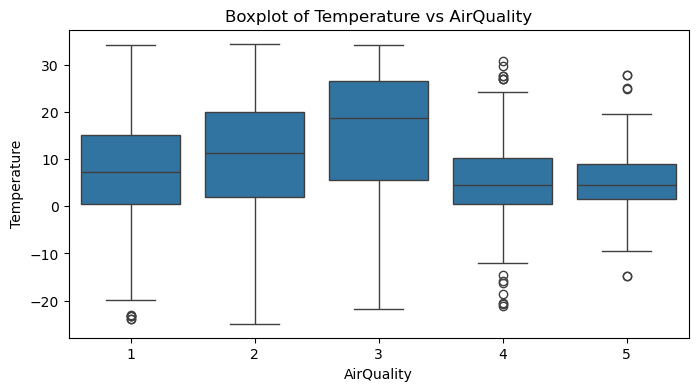

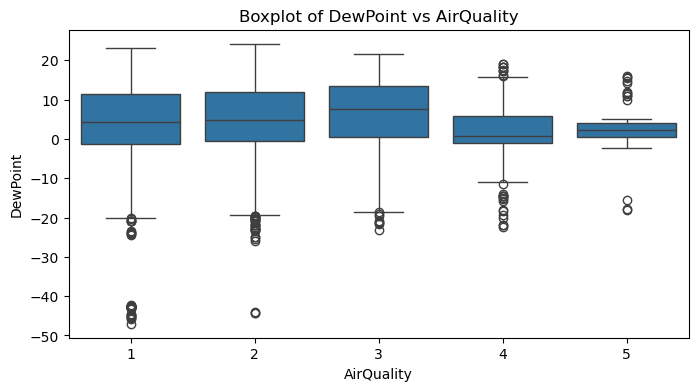

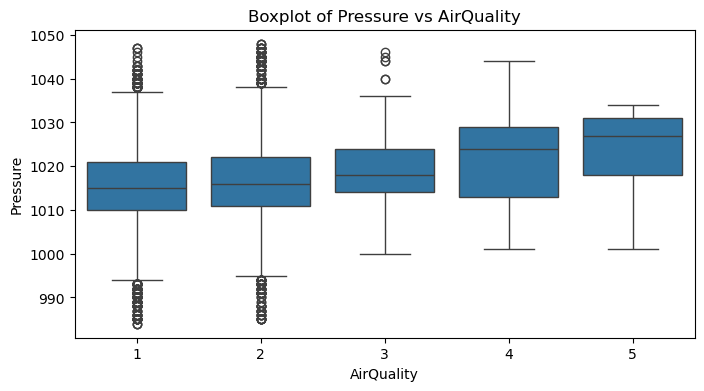

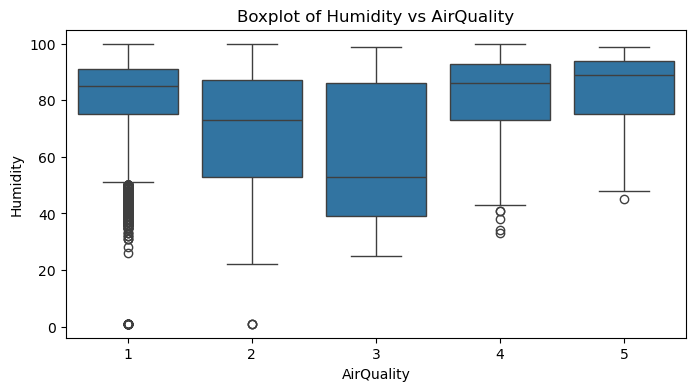

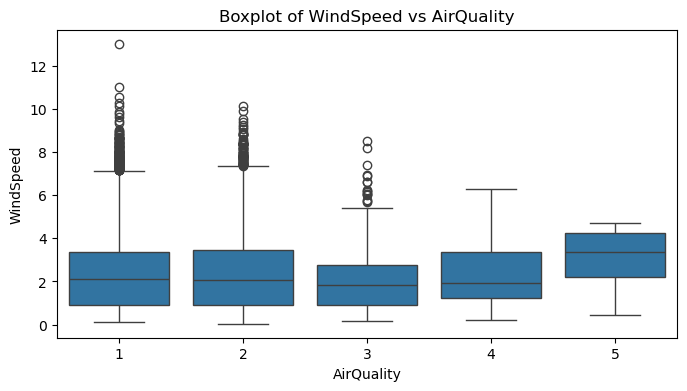

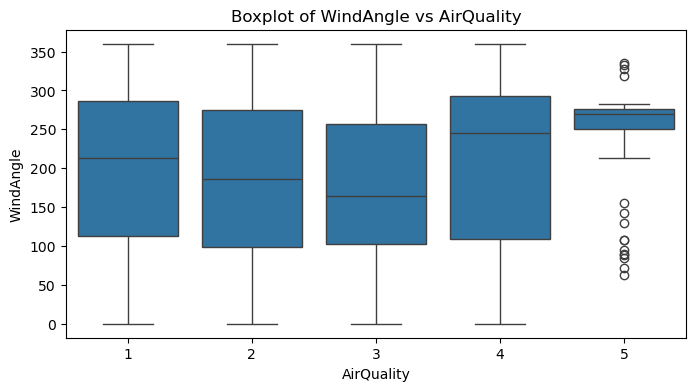

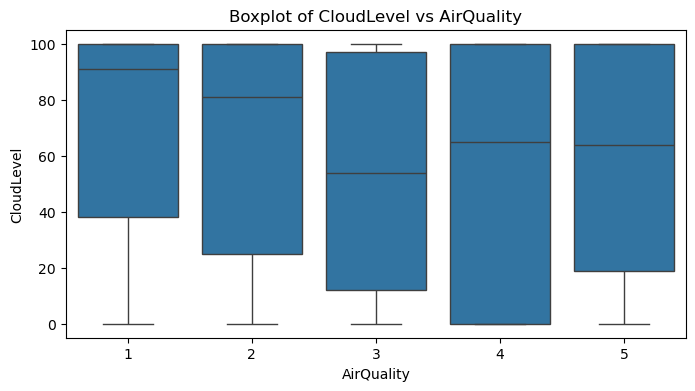

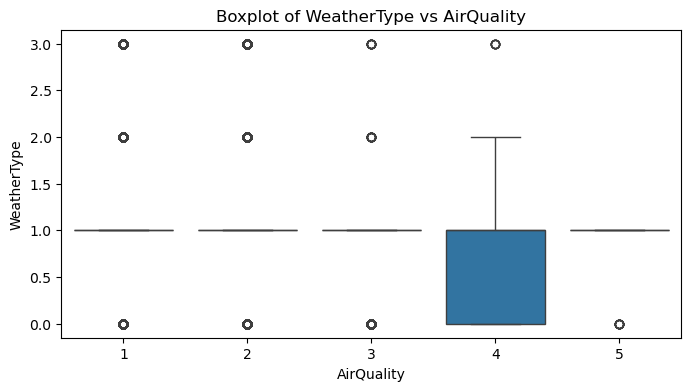

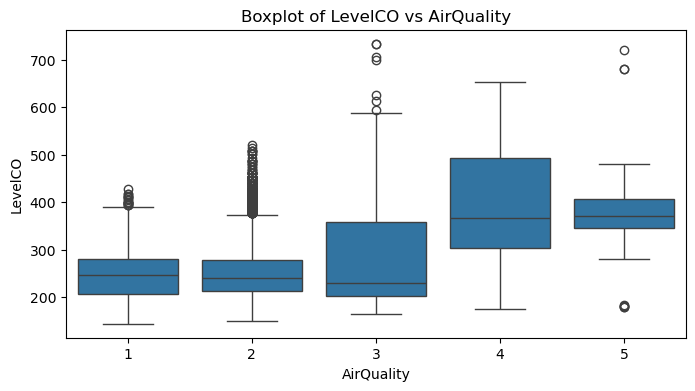

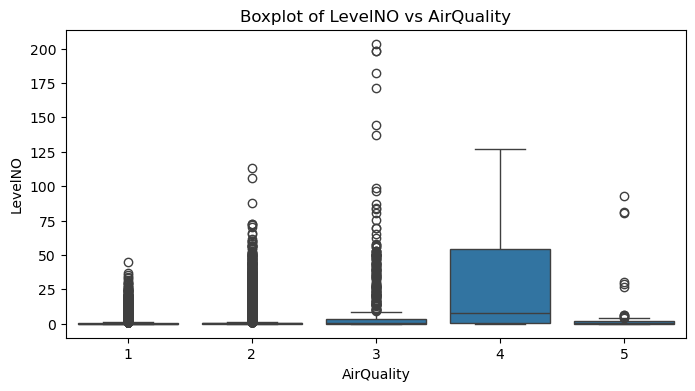

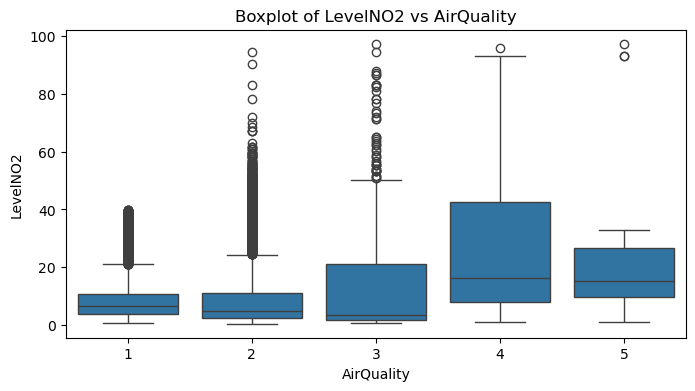

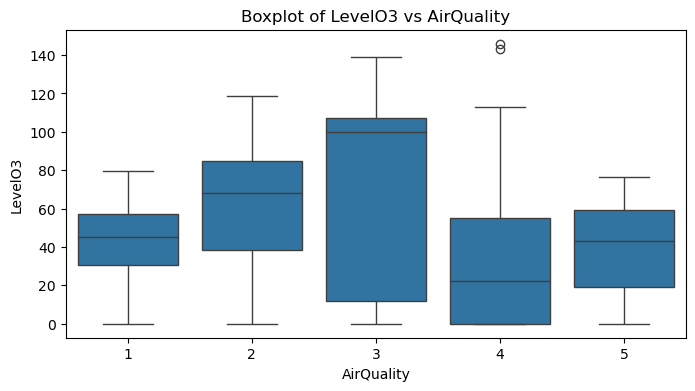

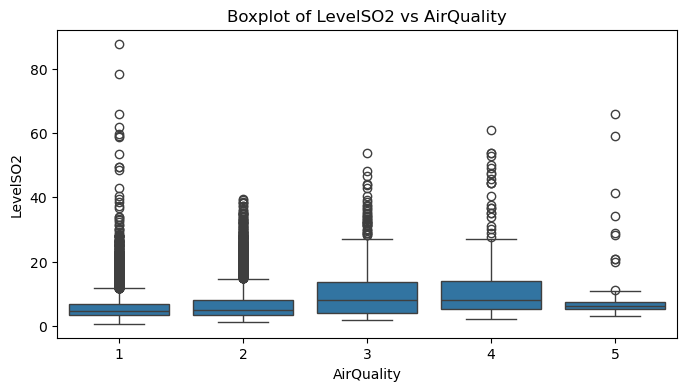

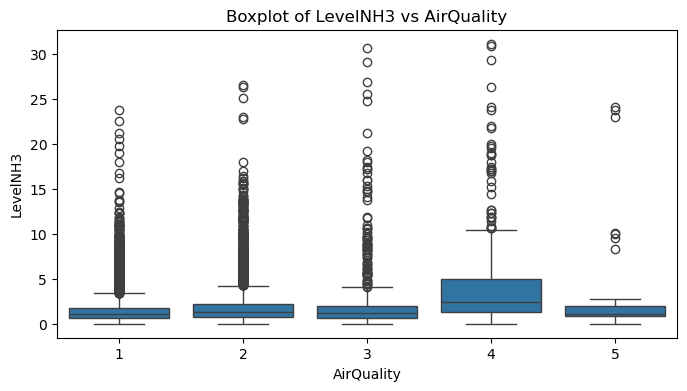

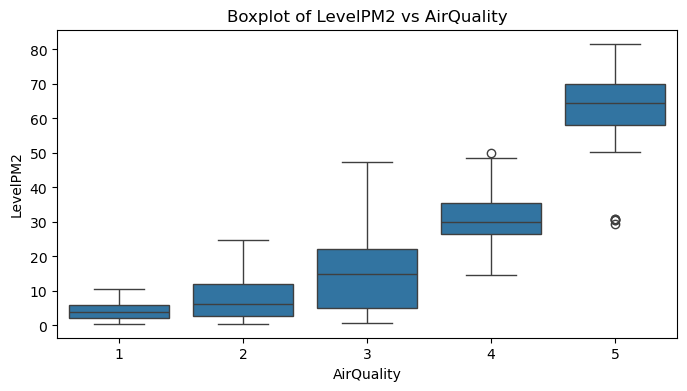

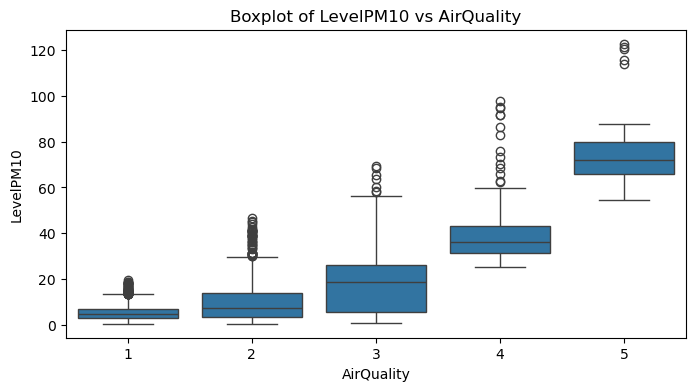

In [17]:
cols = ['Temperature', 'DewPoint', 'Pressure', 'Humidity', 'WindSpeed', 'WindAngle', 'CloudLevel', 'WeatherType', 'LevelCO', 'LevelNO', 'LevelNO2', 'LevelO3', 'LevelSO2', 'LevelNH3', 'LevelPM2', 'LevelPM10']
target = 'AirQuality'
for col in cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col], x=df[target])
    plt.title(f'Boxplot of {col} vs {target}')
    plt.show()

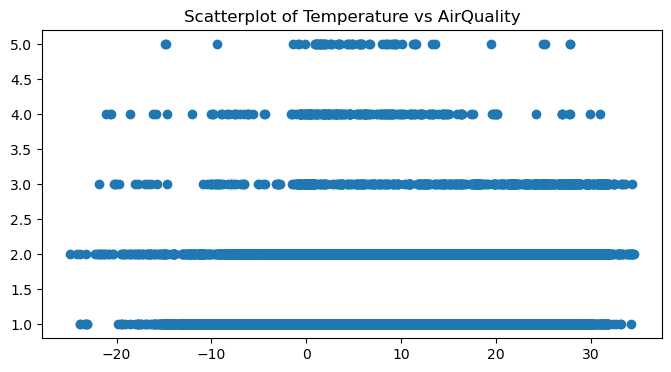

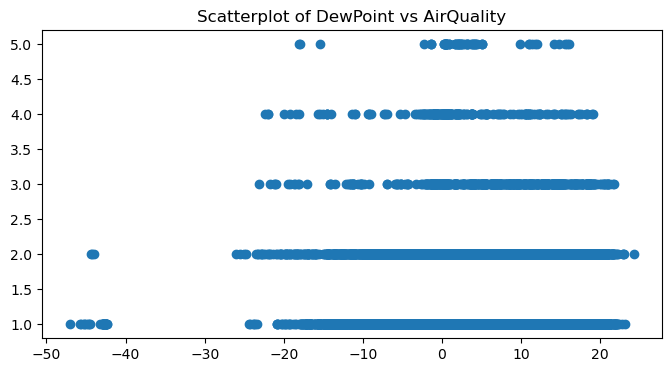

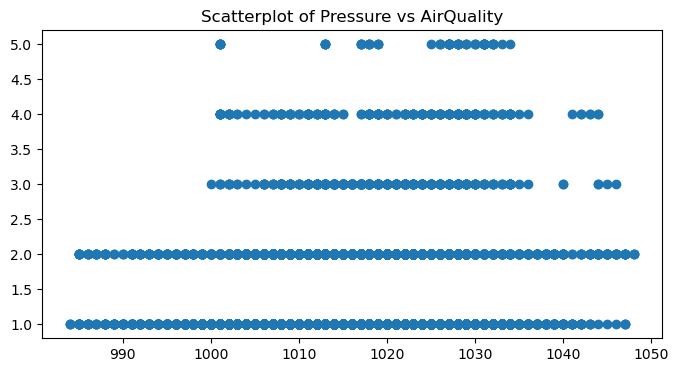

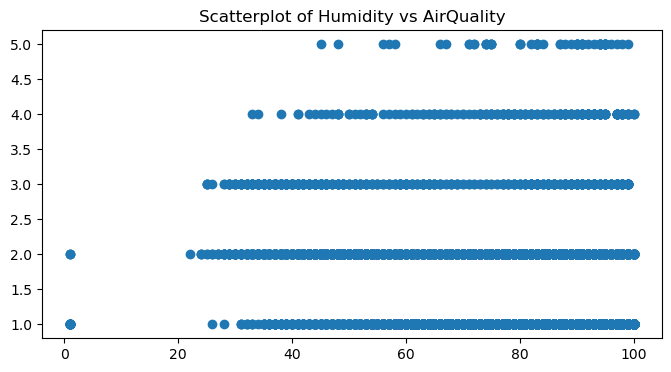

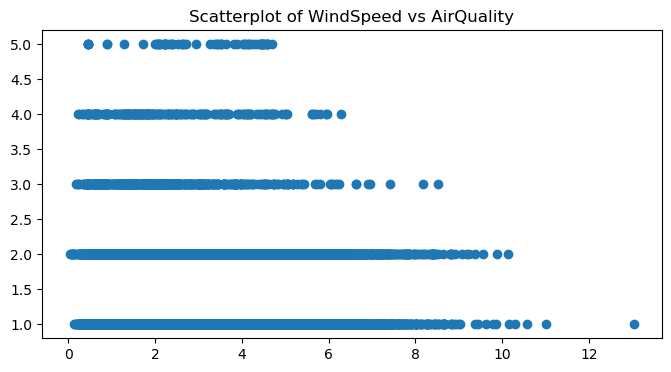

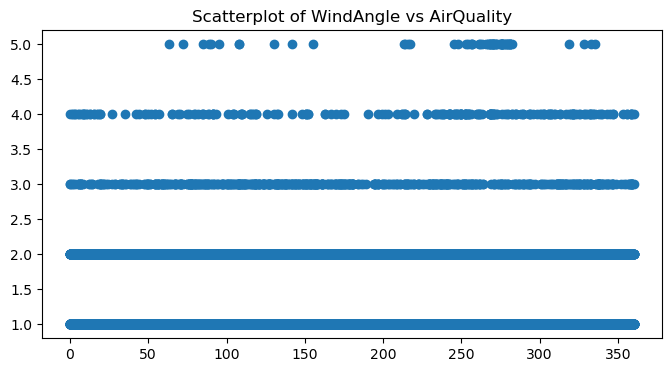

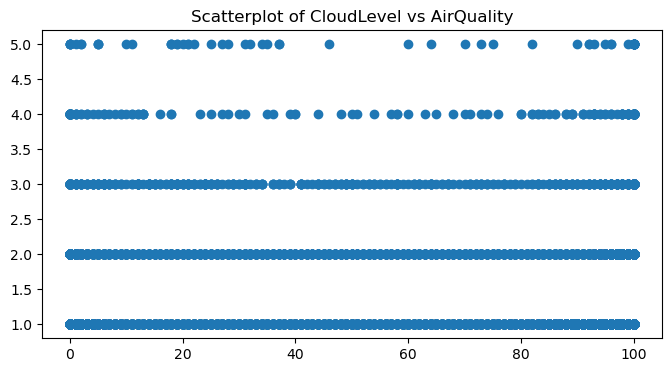

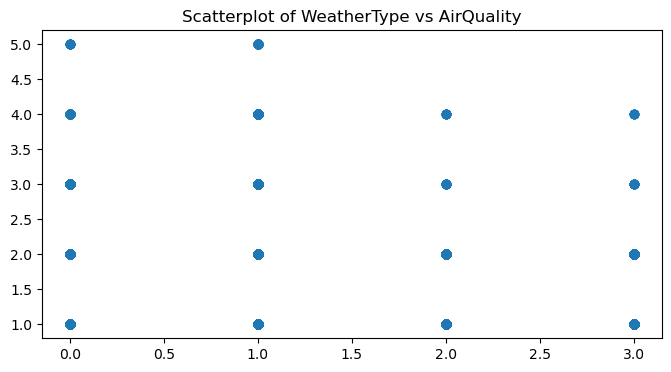

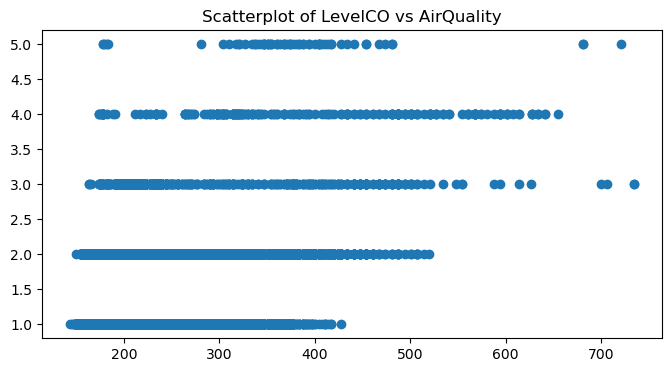

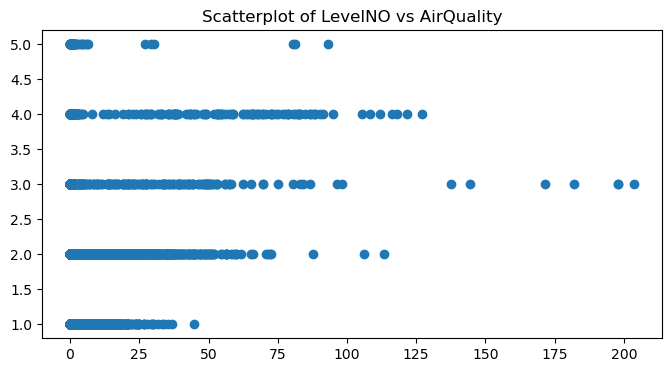

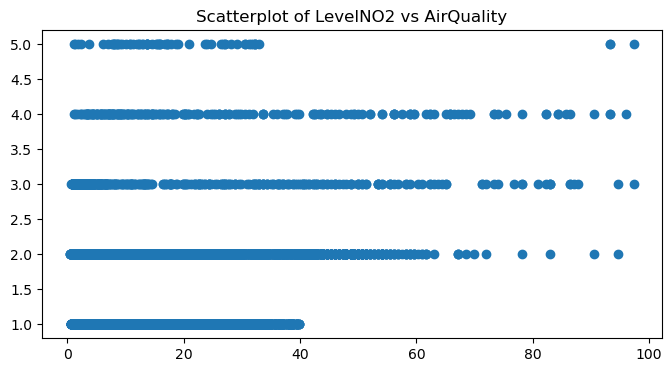

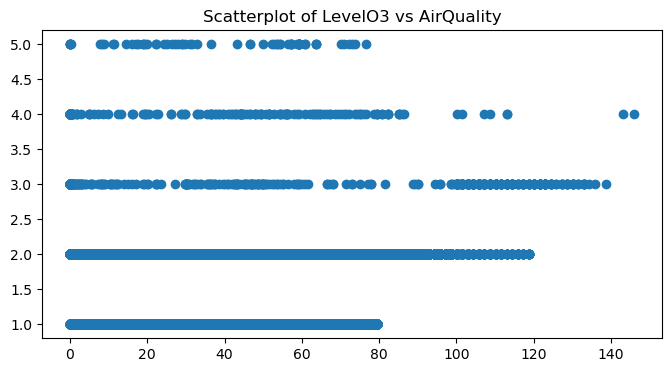

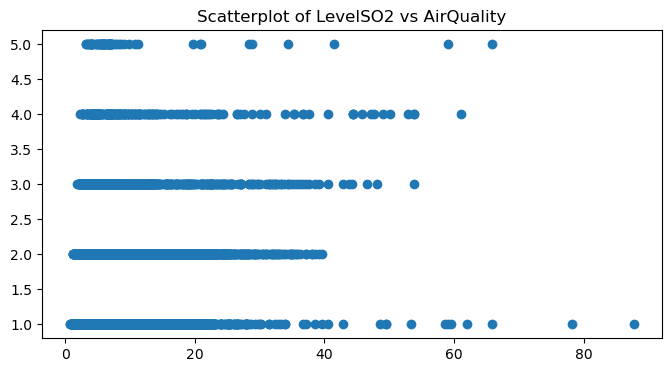

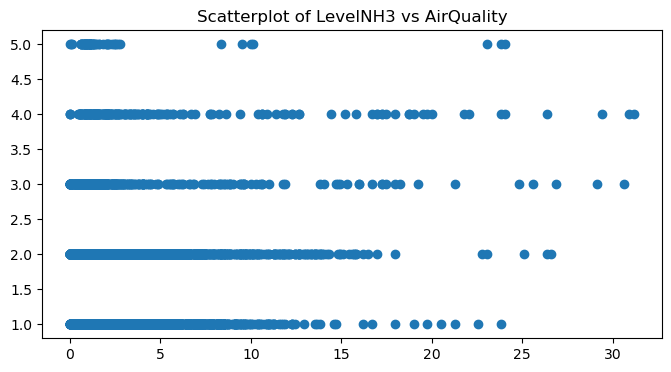

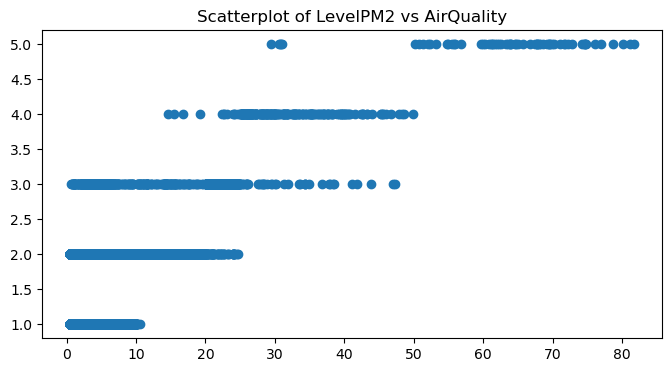

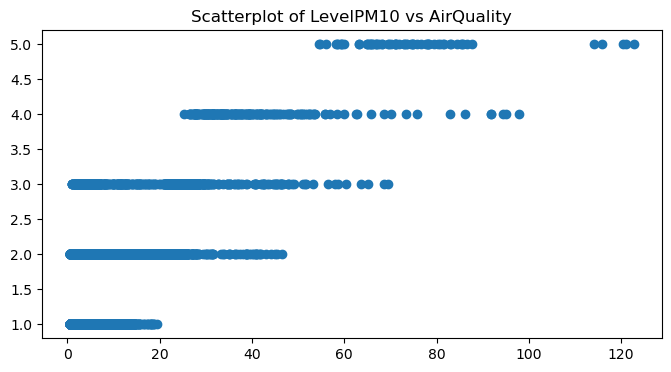

In [18]:
for col in cols:
    plt.figure(figsize=(8, 4))
    plt.scatter(df[col], df[target])
    plt.title(f'Scatterplot of {col} vs {target}')
    plt.show()

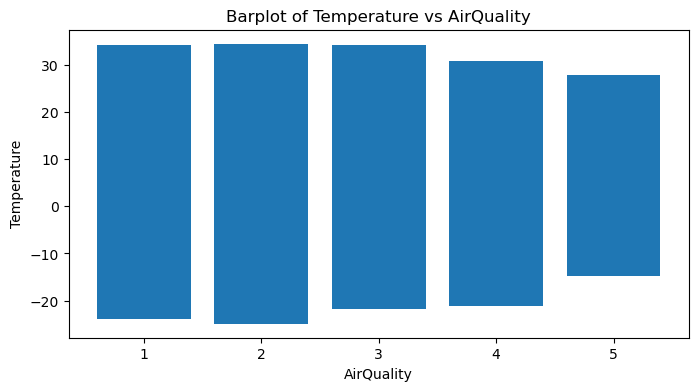

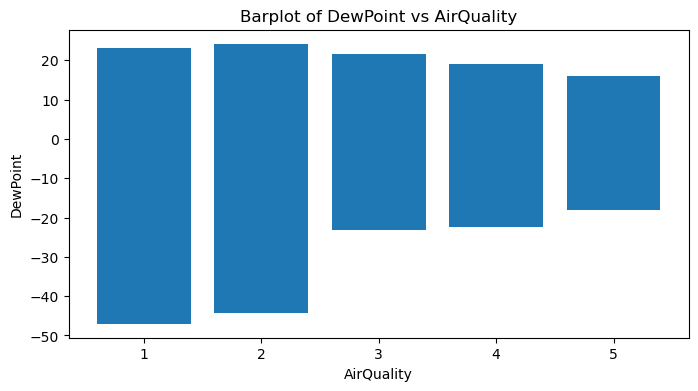

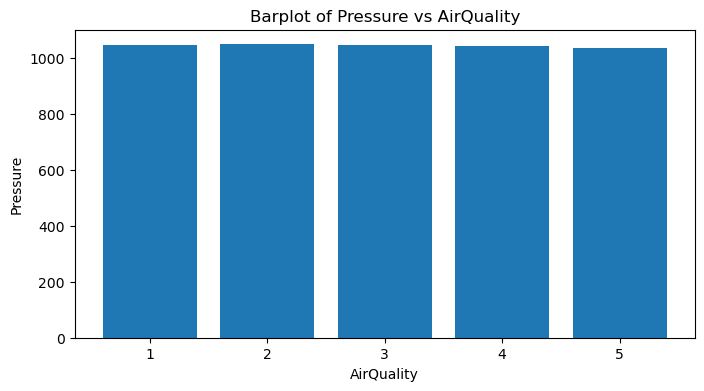

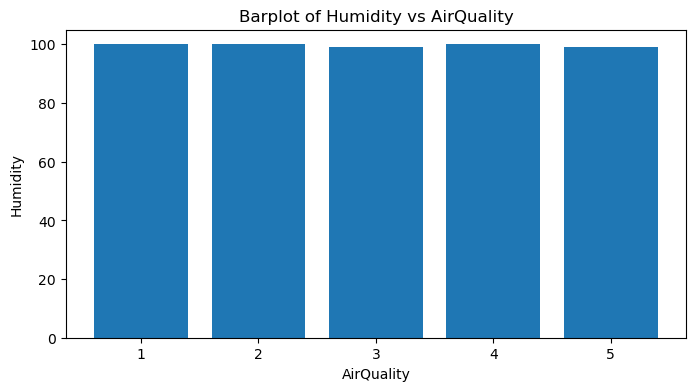

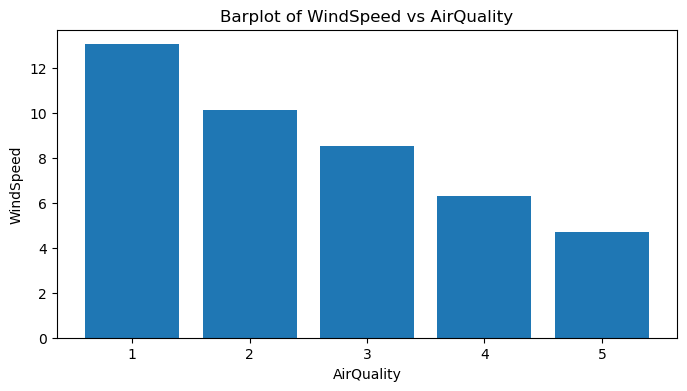

KeyboardInterrupt: 

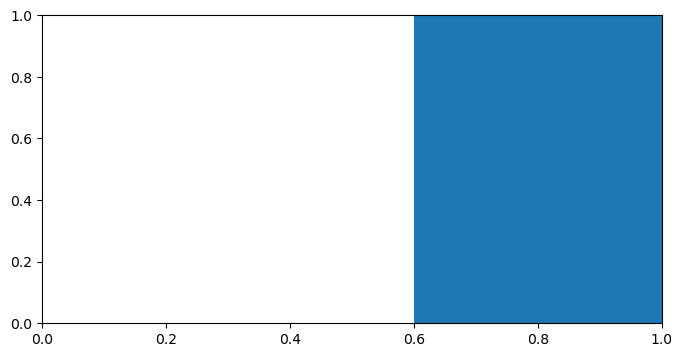

In [19]:
for col in cols:
    plt.figure(figsize=(8, 4))
    plt.bar(df[target], df[col])
    plt.xlabel(target)
    plt.ylabel(col)
    plt.title(f'Barplot of {col} vs {target}')
    plt.show()

# Train Test Split and Handling Class Imbalance

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X = df.drop(['AirQuality', 'UtcTime'], axis=1)
y = df['AirQuality']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (21672, 16)
Testing set shape: (5418, 16)


Target Distribution Before SMOTE

In [ ]:
df['AirQuality'].value_counts()

,count
AirQuality,
1,18129
2,8044
3,625
4,225
5,67


Target Distribution After SMOTE

In [ ]:
print(y_res.value_counts())

AirQuality
1    14503
2    14503
4    14503
3    14503
5    14503
Name: count, dtype: int64




*   The dataset was highly imbalanced, with class 1 dominating and class 5 being the rarest.
*   SMOTE was applied only on the training set to generate synthetic samples and balance all classes equally.
*   After SMOTE, each AirQuality class has 14,503 samples, ensuring that the model can learn equally from all classes without bias.
*   The test set remains untouched for proper evaluation.





# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


*   All features are now standardized to have a mean of 0 and a standard deviation of 1.
*   Scaling is done after applying SMOTE to ensure the synthetic samples are also scaled properly.



# Model Selection

**Logistic Regression on Scaled Data**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_res)

y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)
y_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Train Accuracy:", accuracy_score(y_res, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
#print("ROC-AUC:", roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted'))


Train Accuracy: 0.875363717851479
Test Accuracy: 0.7936507936507936
Precision: 0.8204066794911469
Recall: 0.7936507936507936
F1 Score: 0.803121556479053


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lr_model, X_train_scaled, y_res, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores.mean())

Cross-validation scores: 0.8747017858374131


Observations

*   The training accuracy is a bit higher than the testing accuracy, which is normal and shows only a small amount of overfitting.
*   Precision, Recall, and F1 Score are good, meaning the model predicts most classes fairly well.
*   The cross-validation score is close to the training accuracy, showing the model works well on new data.
*   Logistic Regression can be used as a simple baseline model for predicting the AirQuality index.





**Logistic Regression on Unscaled Data**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_val_score

lr_unscaled = LogisticRegression(max_iter=1500)
lr_unscaled.fit(X_res, y_res)

y_train_pred = lr_unscaled.predict(X_res)
y_test_pred = lr_unscaled.predict(X_test)
y_test_proba = lr_unscaled.predict_proba(X_test)[:, 1]

print("Train Accuracy:", accuracy_score(y_res, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
#print("ROC-AUC:", roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted'))


Train Accuracy: 0.8714197062676687
Test Accuracy: 0.7954964931709118
Precision: 0.8221776759811137
Recall: 0.7954964931709118
F1 Score: 0.8050082726506905


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Observations
*   The results are very similar to the Logistic Regression on scaled data.
*   The model shows a slight warning about convergence because unscaled features.
*   Scaling helps gradient-based models converge faster.





**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_res, y_res)
y_train_pred = rf_model.predict(X_res)
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("Train Accuracy:", accuracy_score(y_res, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

Train Accuracy: 1.0
Test Accuracy: 0.969545957918051
Precision: 0.9708001267518471
Recall: 0.969545957918051
F1 Score: 0.9698948127061531


In [ ]:
cv_scores = cross_val_score(rf_model, X_res, y_res, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores.mean())

Cross-validation scores: 0.9875198234847963


Observation


*   The model achieves almost perfect training accuracy, which is common for Random Forests due to their ability to fit complex patterns.
*   Test accuracy, precision, recall, and F1 score are also very high (~96-97%), showing strong generalization.
*   Compared to Logistic Regression, Random Forest is much more powerful for this dataset and handles complex interactions between features well.
*   Slight overfitting is possible due to nearly perfect training accuracy, but high test accuracy indicates the model is reliable.






**HyperParameter Tuning Using GridSearchCV**

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X_res, y_res)
best_rf = grid_search.best_estimator_
print(best_rf)
y_train_pred = best_rf.predict(X_res)
y_test_pred = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

Fitting 3 folds for each of 72 candidates, totalling 216 fits


KeyboardInterrupt: 

In [ ]:
print("Train Accuracy:", accuracy_score(y_res, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
cv_scores = cross_val_score(best_rf, X_res, y_res, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores.mean())

I am using previous results to save time (47 mins previoulsy).



*   Fitting 3 folds for each of 72 candidates, totalling 216 fits
**RandomForestClassifier(n_estimators=200)**
*   Train Accuracy: 1.0
*   Test Accuracy: 0.9715762273901809
*   Precision: 0.9725900128285445
*   Recall: 0.9715762273901809
*   F1 Score: 0.9718646409203523
*   Cross-validation scores: 0.9875474039853824

**HyperParameter-Tuned RandomForest Classifier**

In [ ]:
new_rf_model = RandomForestClassifier(n_estimators=200)
new_rf_model.fit(X_res, y_res)
y_train_pred = new_rf_model.predict(X_res)
y_test_pred = new_rf_model.predict(X_test)
y_test_proba = new_rf_model.predict_proba(X_test)[:, 1]

print("Train Accuracy:", accuracy_score(y_res, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))
cv_scores = cross_val_score(new_rf_model, X_res, y_res, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores.mean())

Train Accuracy: 1.0
Test Accuracy: 0.9699150978220745
Precision: 0.9710735979273539
Recall: 0.9699150978220745
F1 Score: 0.9702398755962117
Cross-validation scores: 0.987795628490657


Observation
*   The tuned Random Forest achieves perfect training accuracy, which is typical for large Random Forests on balanced datasets.
*   Using 200 trees (n_estimators=200) improves performance slightly compared to the default Random Forest, without overfitting significantly.
*   This tuned Random Forest is currently the best-performing model for predicting AirQuality in this dataset.





**XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
y_res_adjusted = y_res - 1
y_test_adjusted = y_test - 1

xgb_model.fit(X_res, y_res_adjusted)

y_train_pred = xgb_model.predict(X_res)
y_test_pred = xgb_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_res_adjusted, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test_adjusted, y_test_pred))
print("Precision:", precision_score(y_test_adjusted, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test_adjusted, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test_adjusted, y_test_pred, average='weighted'))
cv_scores = cross_val_score(xgb_model, X_res, y_res_adjusted, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores.mean())


Train Accuracy: 0.9981796869613183
Test Accuracy: 0.9630860095976375
Precision: 0.9641051589743425
Recall: 0.9630860095976375
F1 Score: 0.9633976262178572
Cross-validation scores: 0.9864303937116459


Observation
*   The XGBoost model achieves very high training accuracy and strong test performance.
*   Compared to Random Forest, XGBoost performs slightly lower on test accuracy but still a strong performer for this task.
*   Label adjustment (y-1) is neccessary because XGBoost expects class labels starting from 0 for multi-class classification.




**Overall Summary:**

* **Logistic Regression** is simple and fast but less accurate (~79-80% test accuracy).
* **Random Forest** performs much better (~97% test accuracy) and can capture complex relationships in the data.
* **Hyperparameter tuning** (***n_estimators = 200***) improved Random Forest slightly.
* **XGBoost** is also strong (~96% test accuracy), slightly lower than tuned Random Forest.
* **Conclusion:** Tuned Random Forest is the **best choice** for predicting AirQuality, balancing accuracy, precision, and reliability.


# Submission

**Data Preparation for Submission**

In [ ]:
test_data = pd.read_csv("test.csv")
test_utctime = test_data['UtcTime']
test_data = test_data.drop(columns=['UtcTime', 'LocalDate', 'LocalHour', 'SineDay', 'CosineDay', 'SineWeek', 'CosineWeek', 'SineMonth', 'CosineMonth', 'SineYear', 'CosineYear', 'WindSine', 'WindCosine', 'dt'])




*   Load the test dataset.
*   Keep track of 'UtcTime' for the submission file.
*   Drop unneccessary columns taht were not used in model training.





In [ ]:
test_data.head()

,Temperature,DewPoint,Pressure,Humidity,WindSpeed,WindAngle,CloudLevel,WeatherType,LevelCO,LevelNO,LevelNO2,LevelO3,LevelSO2,LevelNH3,LevelPM2,LevelPM10
0,2.17,-0.07,1017,85,0.45,222,43,Clouds,270.37,0.02,10.97,43.63,4.17,0.63,3.96,5.24
1,2.63,-0.72,1016,78,4.77,232,91,Clouds,267.03,0.01,9.08,48.64,3.13,0.66,2.97,4.10
2,2.83,-0.70,1016,77,4.71,237,94,Clouds,270.37,0.01,7.28,50.78,2.59,0.64,2.77,3.81
3,3.98,0.50,1016,78,4.92,245,100,Clouds,270.37,0.00,5.18,53.64,2.26,0.55,2.91,3.84
4,4.03,0.72,1015,79,4.83,250,100,Clouds,270.37,0.00,4.33,55.07,2.29,0.49,3.18,4.02


Encode categorical features like 'WeatherType'

In [ ]:
le = LabelEncoder()
test_data['WeatherType'] = le.fit_transform(test_data['WeatherType'])

**Model Selection and Prediction**

Trained the models to predict AirQuality on the test dataset.


*   XGBoost
*   Random Forest



Using XGBoost as Model

In [ ]:
predictions = xgb_model.predict(test_data)
final_submission = pd.DataFrame({"UtcTime":test_utctime, "AirQuality":predictions+1})
final_submission.to_csv("final_submission.csv", index=False)
print("CSV file created successfully.")

CSV file created successfully.




*   Predicted AirQuality using the XGBoost model.
*   Added 1 to predictions beacause of labels adjustments.
*   Prepared submission file with 'UtcTime' and predicted 'AirQuality'.





Using RandomForest Classifier as Model

In [ ]:
predictions = new_rf_model.predict(test_data)
submission_rf = pd.DataFrame({"UtcTime":test_utctime, "AirQuality":predictions})
submission_rf.to_csv("submission_rf.csv", index=False)
print("RF CSV file created successfully.")

RF CSV file created successfully.




*   Predicted AirQuality using the Random Forest model.
*   Prepared submission file with 'UtcTime' and predicted 'AirQuality'.



